<html> <h1 style="font-style:bold; color:blue;"> Machine Learning in Finance </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-10 - Wait-Attention (Flat-Trend) - Gold - LSTM </h1> </html>

## Gold  - Period: 01/01/2024 - 30/06/2024
5-minutes time-frame
     
### Predictions of Flat-Trend
- target take-profit = $10
- Early-Stopping
- Loss function: BinaryCrossentropy
- Metrics: Accuracy and (F1, Precision, Recall)

### length of analysed history (sliding window)- 50 raws ago

#### dataset: 35232 rows (5-minutes)
#### use part of the dataset: 12000 rows, which is around 2 months
#### train / test = 90 /10

In [85]:
# epoch = 30
# patience = 10
# take-profit = $10
# hours = 4


Now just press 'CTRL' and 'ENTER' keys on the next 3 cells with code.

In [86]:
# For Google Colab only!

!cat /proc/driver/nvidia/gpus/0000:00:04.0/information

Model: 		 Unknown
IRQ:   		 11
GPU UUID: 	 GPU-8d57706e-c85f-e651-3184-6dd61d8e01eb
Video BIOS: 	 90.04.a7.00.01
Bus Type: 	 PCI
DMA Size: 	 47 bits
DMA Mask: 	 0x7fffffffffff
Bus Location: 	 0000:00:04.0
Device Minor: 	 0
GPU Excluded:	 No


In [87]:
# Use code in this cell for Google Colab only

# Run the cell twice and upload 2 files:
# XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv
# XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv

from google.colab import files
uploaded = files.upload()

Saving XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv to XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30 (1).csv
Saving XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv to XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30 (1).csv


In [88]:
# The cell with the result for comparison (do not run)

In [89]:
# Use code in this cell for Google Colab only
!ls

 sample_data
'XAGUSD_5 Mins_Ask_2023.01.01_2023.06.30 (1).csv'
'XAGUSD_5 Mins_Bid_2023.01.01_2023.06.30.csv'
'XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30 (1).csv'
'XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv'
'XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30 (1).csv'
'XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv'


In [90]:
# The cell with the result for comparison (do not run)

....................................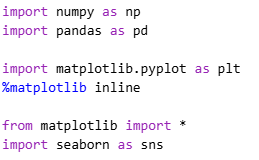

In [91]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib import*
import seaborn as sns

In [92]:
# Each subsequent cell with the result for comparison (do not run)

......................................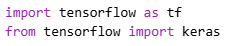

In [93]:
import tensorflow as tf
from tensorflow import keras

..............................image.png

In [94]:
print(tf.__version__)

2.19.0


....................................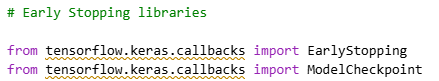

In [95]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

................................image.png

In [96]:
np.random.seed(19)

...................................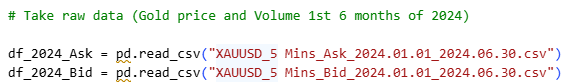

In [97]:
df_2024_Ask = pd.read_csv("XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv")
df_2024_Bid = pd.read_csv("XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv")

................................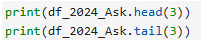

In [98]:
print(df_2024_Ask.head(3))
print(df_2024_Ask.tail(3))

            Time (UTC)      Open      High       Low     Close  Volume 
0  2024.01.01 23:00:00  2064.562  2067.475  2064.075  2065.686  0.11843
1  2024.01.01 23:05:00  2065.616  2065.839  2064.476  2064.902  0.06906
2  2024.01.01 23:10:00  2064.902  2066.825  2064.752  2066.105  0.04203
                Time (UTC)      Open      High       Low     Close  Volume 
35229  2024.06.30 23:45:00  2326.026  2326.315  2325.875  2325.945  0.02538
35230  2024.06.30 23:50:00  2325.945  2325.945  2325.555  2325.795  0.02880
35231  2024.06.30 23:55:00  2325.825  2325.835  2325.066  2325.245  0.07257


....................................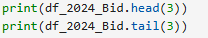

In [99]:
print(df_2024_Bid.head(3))
print(df_2024_Bid.tail(3))

            Time (UTC)      Open      High       Low     Close  Volume 
0  2024.01.01 23:00:00  2062.598  2066.595  2062.405  2065.214  0.12012
1  2024.01.01 23:05:00  2065.185  2065.194  2063.851  2064.455  0.06508
2  2024.01.01 23:10:00  2064.424  2066.365  2064.395  2065.734  0.03945
                Time (UTC)      Open      High       Low     Close  Volume 
35229  2024.06.30 23:45:00  2325.645  2325.905  2325.465  2325.525  0.06891
35230  2024.06.30 23:50:00  2325.515  2325.525  2325.125  2325.385  0.09813
35231  2024.06.30 23:55:00  2325.438  2325.438  2324.625  2324.825  0.07851


<html> <h3 style="font-style:italic; color:blue;"> Merge DataFrame </h3> </html>

In [100]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 2 cells.

In [101]:
# Rename columns to distinguish bid/ask

df_2024_Ask.columns = ['Local_time', 'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask']
df_2024_Bid.columns = ['Local_time', 'Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid']


In [102]:
#(!! DO ONLY ONCE)
# Merge on common time column

data = df_2024_Bid.merge(df_2024_Ask, left_on='Local_time', right_on='Local_time', how='outer')

data

,Local_time,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask
0,2024.01.01 23:00:00,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843
1,2024.01.01 23:05:00,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906
2,2024.01.01 23:10:00,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203
3,2024.01.01 23:15:00,2065.715,2066.075,2065.055,2065.585,0.04386,2066.105,2066.525,2065.415,2065.986,0.03201
4,2024.01.01 23:20:00,2065.585,2065.815,2065.295,2065.555,0.03171,2065.992,2066.242,2065.645,2065.855,0.03309
...,...,...,...,...,...,...,...,...,...,...,...
35227,2024.06.30 23:35:00,2325.005,2326.035,2324.905,2325.625,0.07389,2325.425,2326.455,2325.345,2326.065,0.07116
35228,2024.06.30 23:40:00,2325.625,2325.755,2325.165,2325.575,0.06771,2326.045,2326.202,2325.595,2325.965,0.04635
35229,2024.06.30 23:45:00,2325.645,2325.905,2325.465,2325.525,0.06891,2326.026,2326.315,2325.875,2325.945,0.02538
35230,2024.06.30 23:50:00,2325.515,2325.525,2325.125,2325.385,0.09813,2325.945,2325.945,2325.555,2325.795,0.02880


In [103]:
# cell with the result for comparison (do not run)


...............................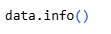

In [104]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Local_time  35232 non-null  object 
 1   Open_Bid    35232 non-null  float64
 2   High_Bid    35232 non-null  float64
 3   Low_Bid     35232 non-null  float64
 4   Close_Bid   35232 non-null  float64
 5   Volume_Bid  35232 non-null  float64
 6   Open_Ask    35232 non-null  float64
 7   High_Ask    35232 non-null  float64
 8   Low_Ask     35232 non-null  float64
 9   Close_Ask   35232 non-null  float64
 10  Volume_Ask  35232 non-null  float64
dtypes: float64(10), object(1)
memory usage: 3.0+ MB


In [105]:
# No NaN elements !

In [106]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 2 cells.

In [107]:
# Delta of trading volumes (as well as the modulus of this delta) between Ask
# and Bid volumes are added as additional parameters

data["Volume_Delta"] = data["Volume_Ask"] - data["Volume_Bid"]
data["Volume_Delta_abs"] = (data["Volume_Ask"] - data["Volume_Bid"]).abs()

In [108]:
data["Open_Delta"] = data["Open_Ask"]  - data["Open_Bid"]
data["High_Delta"] = data["High_Ask"]  - data["High_Bid"]
data["Low_Delta"]  = data["Low_Ask"]   - data["Low_Bid"]
data["Close_Delta"]= data["Close_Ask"] - data["Close_Bid"]

.........................image.png

In [109]:
data.describe()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta
count,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000
mean,2205.889710,2206.645921,2205.128739,2205.897065,0.152156,2206.249356,2207.005264,2205.487844,2206.256846,0.152062,-0.000094,0.085480,0.359646,0.359343,0.359105,0.359781
std,142.978742,143.165839,142.780793,142.978152,0.159003,143.005802,143.192352,142.808660,143.005909,0.156439,0.130376,0.098443,0.105919,0.085914,0.090534,0.086697
min,1985.635000,1986.595000,1984.088000,1985.625000,0.000000,1985.915000,1986.945000,1984.475000,1985.915000,0.000000,-1.064400,0.000000,0.001000,0.042000,0.001000,0.075000
25%,2035.855000,2036.333250,2035.385000,2035.855000,0.046255,2036.195000,2036.675000,2035.722000,2036.195000,0.049140,-0.051012,0.017700,0.317000,0.320000,0.320000,0.320000
50%,2255.281500,2256.425000,2254.270000,2255.301500,0.098350,2255.650000,2256.758500,2254.608500,2255.660000,0.101700,0.001105,0.052920,0.350000,0.350000,0.350000,0.350000
75%,2333.475000,2334.292250,2332.639750,2333.477500,0.199250,2333.878250,2334.685250,2333.005000,2333.886750,0.196412,0.054670,0.118320,0.387000,0.387000,0.387000,0.387000
max,2449.735000,2449.985000,2447.555000,2449.758000,1.485490,2450.185000,2450.325000,2447.966000,2450.165000,2.842680,2.703590,2.703590,5.981000,5.981000,5.981000,5.981000


.........................image.png

In [110]:
data.shape

(35232, 17)

............................image.png

In [111]:
data.head(3)

,Local_time,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta
0,2024.01.01 23:00:00,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472
1,2024.01.01 23:05:00,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447
2,2024.01.01 23:10:00,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371


<html> <h3 style="font-style:italic; color:blue;"> Date transformation </h3> </html>

...............................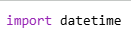

In [112]:
import datetime

...............................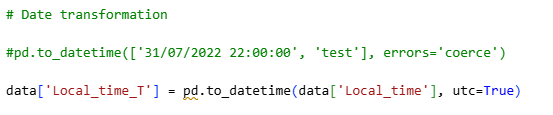

In [113]:
data['Local_time_T'] = pd.to_datetime(data['Local_time'], utc=True)

..........................................image.png

In [114]:
data=data.drop(['Local_time'],axis=1)

_______________________image.png

In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   Open_Bid          35232 non-null  float64            
 1   High_Bid          35232 non-null  float64            
 2   Low_Bid           35232 non-null  float64            
 3   Close_Bid         35232 non-null  float64            
 4   Volume_Bid        35232 non-null  float64            
 5   Open_Ask          35232 non-null  float64            
 6   High_Ask          35232 non-null  float64            
 7   Low_Ask           35232 non-null  float64            
 8   Close_Ask         35232 non-null  float64            
 9   Volume_Ask        35232 non-null  float64            
 10  Volume_Delta      35232 non-null  float64            
 11  Volume_Delta_abs  35232 non-null  float64            
 12  Open_Delta        35232 non-null  float64            
 13  H

<html> <h3 style="font-style:italic; color:blue;"> Data Visualisation </h3> </html>

In [116]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 3 cells.

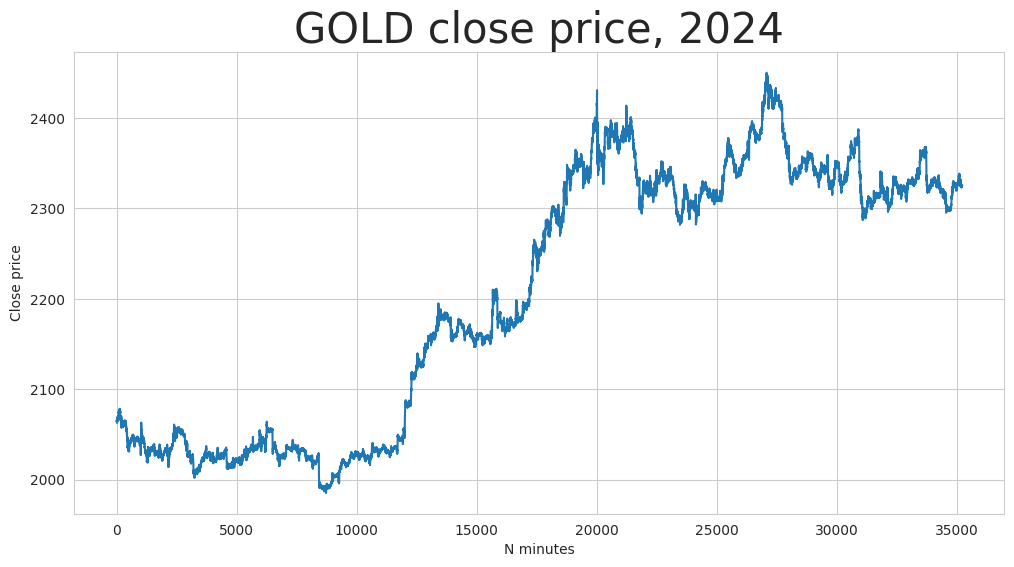

In [117]:
plt.figure(figsize=(12,6))
plt.plot(data['Close_Bid'])
plt.title('GOLD close price, 2024')
plt.xlabel('N minutes')
plt.ylabel('Close price')
plt.show()

<Figure size 900x400 with 0 Axes>

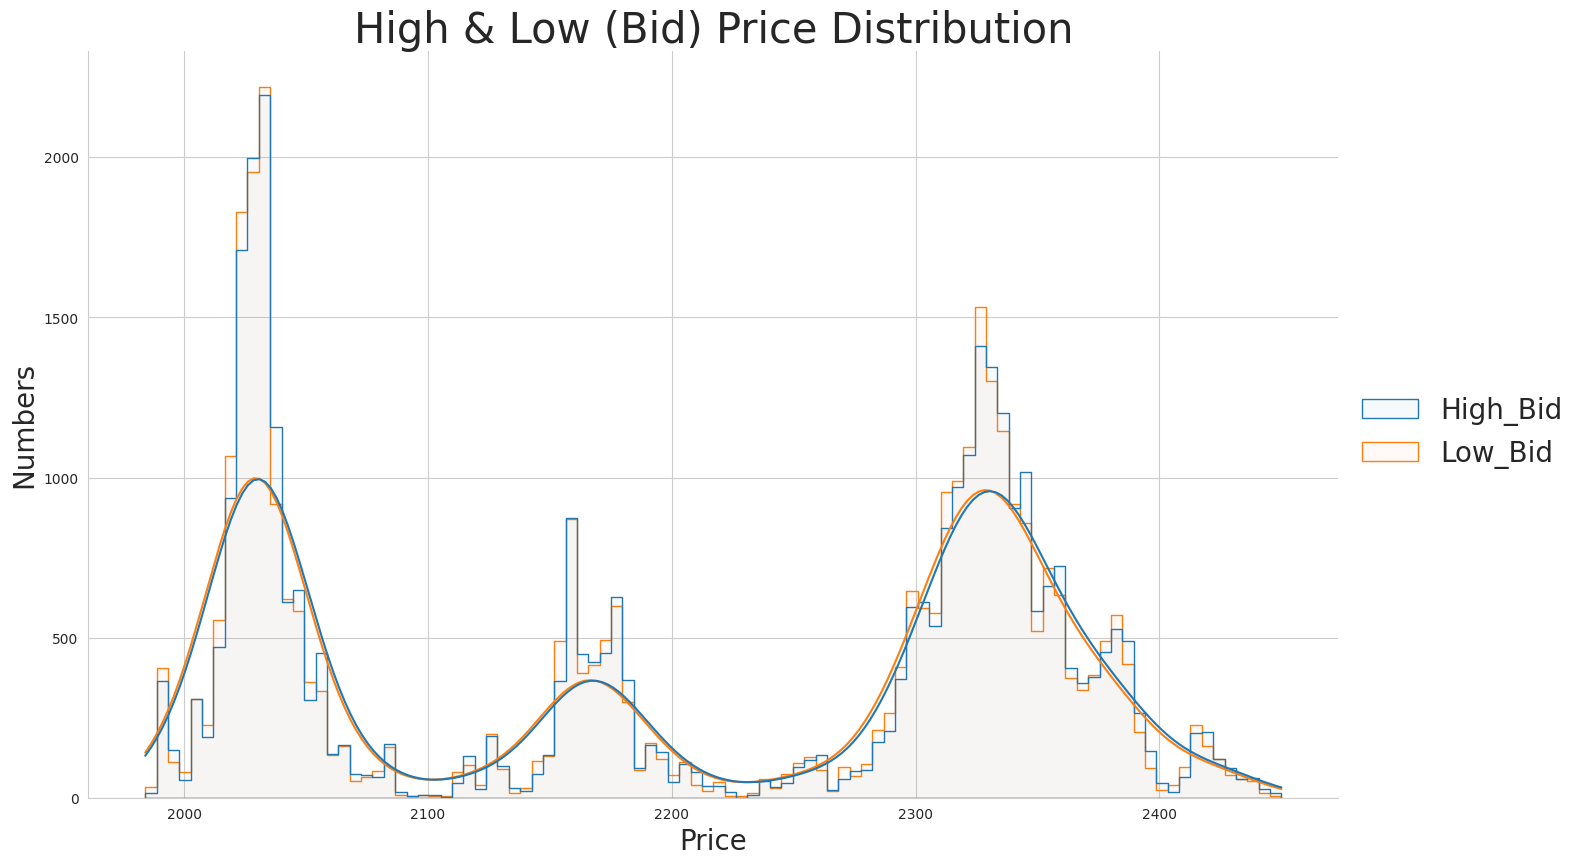

In [118]:
fig = plt.figure(figsize=(9, 4))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data[['High_Bid', 'Low_Bid']],
            height=8,
            aspect=1.7,
            #hue="species",
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('High & Low (Bid) Price Distribution')
plt.xlabel('Price', size= 20)
#plt.ylabel('count (%)')
plt.ylabel('Numbers', size= 20)
plt.show();

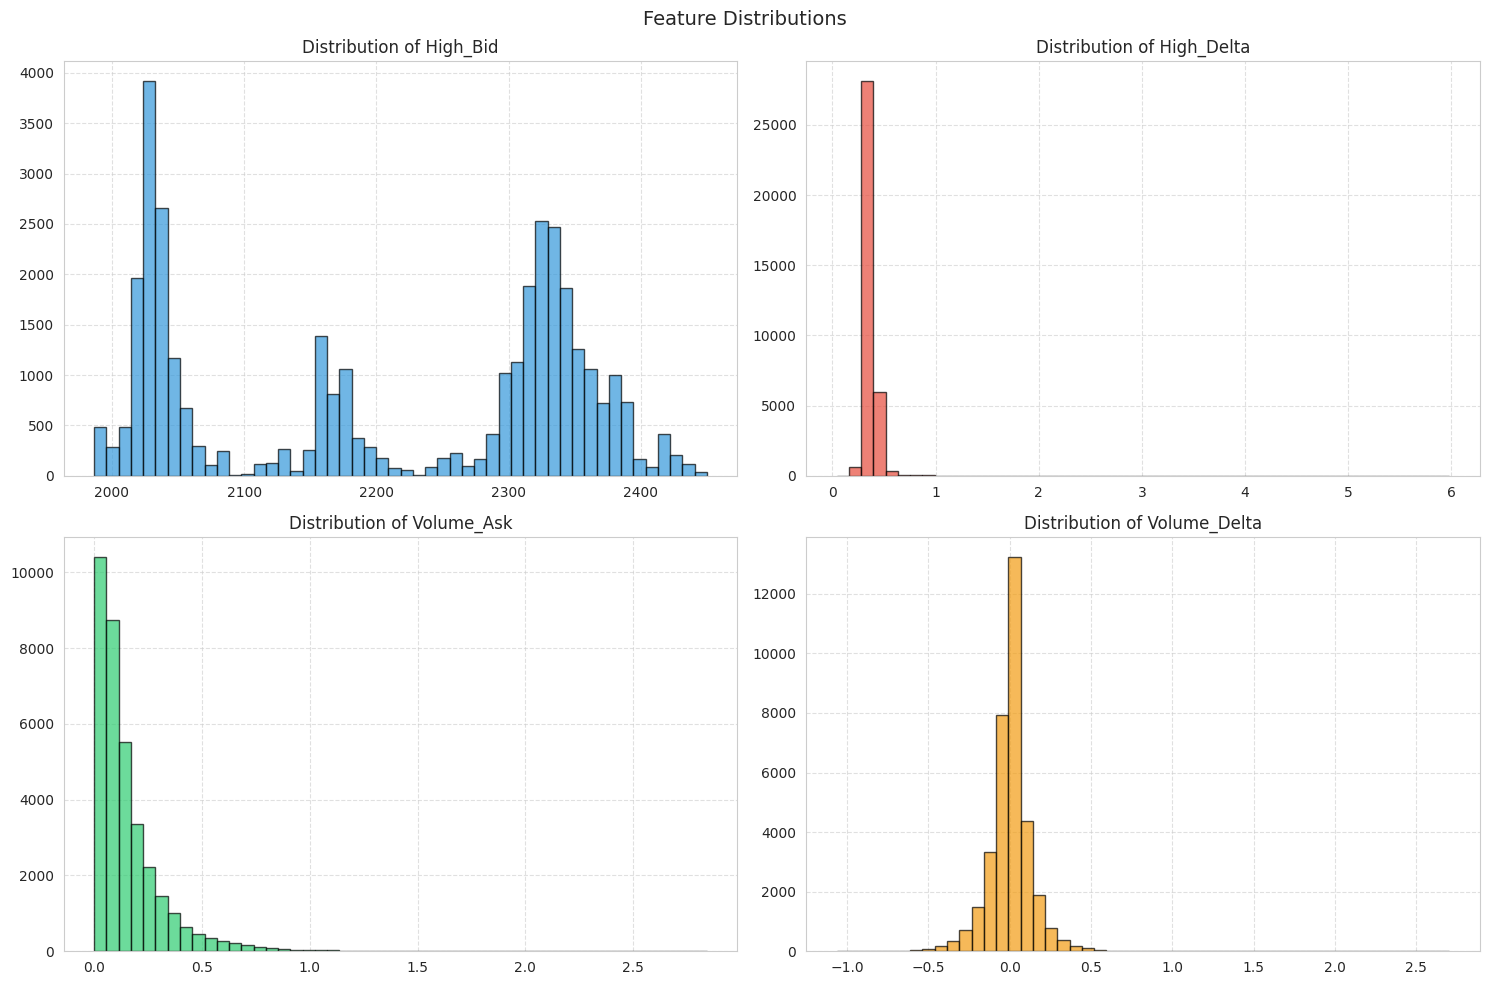

In [119]:
# Plot histograms for some features

plt.figure(figsize=(15, 10))
features = data[['High_Bid', 'High_Delta', 'Volume_Ask', 'Volume_Delta']]
features_to_plot = ['High_Bid', 'High_Delta', 'Volume_Ask', 'Volume_Delta']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, col in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    #plt.hist(features_to_plot, bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    plt.hist(features[col], bins=50, color=colors[i], edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

<html> <h3 style="font-style:italic; color:blue;"> Indicate starts of days and weeks </h3> </html>

_________________________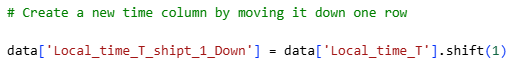

In [120]:
data['Local_time_T_shipt_1_Down'] = data['Local_time_T'].shift(1)

In [121]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [122]:
# calculate the time interval with the previous raw

data["Local_time_T_Delta"] = data["Local_time_T"] - data["Local_time_T_shipt_1_Down"]

..................................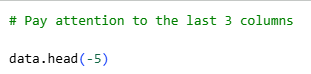

In [123]:
data.head(-5)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00,NaT,NaT
1,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447,2024-01-01 23:05:00+00:00,2024-01-01 23:00:00+00:00,0 days 00:05:00
2,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371,2024-01-01 23:10:00+00:00,2024-01-01 23:05:00+00:00,0 days 00:05:00
3,2065.715,2066.075,2065.055,2065.585,0.04386,2066.105,2066.525,2065.415,2065.986,0.03201,-0.01185,0.01185,0.390,0.450,0.360,0.401,2024-01-01 23:15:00+00:00,2024-01-01 23:10:00+00:00,0 days 00:05:00
4,2065.585,2065.815,2065.295,2065.555,0.03171,2065.992,2066.242,2065.645,2065.855,0.03309,0.00138,0.00138,0.407,0.427,0.350,0.300,2024-01-01 23:20:00+00:00,2024-01-01 23:15:00+00:00,0 days 00:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35222,2324.145,2325.445,2324.145,2325.395,0.04935,2324.635,2325.865,2324.635,2325.835,0.05331,0.00396,0.00396,0.490,0.420,0.490,0.440,2024-06-30 23:10:00+00:00,2024-06-30 23:05:00+00:00,0 days 00:05:00
35223,2325.395,2325.465,2324.955,2325.005,0.04422,2325.815,2325.905,2325.355,2325.425,0.02031,-0.02391,0.02391,0.420,0.440,0.400,0.420,2024-06-30 23:15:00+00:00,2024-06-30 23:10:00+00:00,0 days 00:05:00
35224,2324.945,2325.135,2324.655,2325.005,0.01317,2325.355,2325.525,2325.095,2325.415,0.01059,-0.00258,0.00258,0.410,0.390,0.440,0.410,2024-06-30 23:20:00+00:00,2024-06-30 23:15:00+00:00,0 days 00:05:00
35225,2324.975,2325.115,2324.835,2325.055,0.01080,2325.385,2325.525,2325.245,2325.475,0.00846,-0.00234,0.00234,0.410,0.410,0.410,0.420,2024-06-30 23:25:00+00:00,2024-06-30 23:20:00+00:00,0 days 00:05:00


..............................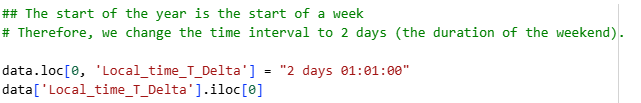

In [124]:
data.loc[0, 'Local_time_T_Delta'] = "2 days 01:01:00"
data['Local_time_T_Delta'].iloc[0]

Timedelta('2 days 01:01:00')

In [125]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [126]:
# find intervals which are longer than 5 minutes
# create a new DataFrame with the beginning of the new days

new_day = data[['Local_time_T_Delta']][data["Local_time_T_Delta"] > '0 days 00:05:00']
new_day['Local_time_T_Delta'].value_counts(sort=False)

,count
Local_time_T_Delta,
2 days 01:01:00,1
0 days 01:05:00,98
2 days 01:05:00,24
0 days 03:35:00,4
2 days 00:05:00,1
3 days 01:05:00,1


In [127]:
# cell with the result for comparison (do not run)

In [128]:
# We found the duration of night intervals when there is no trading in Gold.
# Total such intervals - 129, which is equal to the number of trading days during 6 first months of 2024

In [129]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [130]:
# find intervals which are longer than 1 day
# create a new DataFrame with the beginning of the new weeks

new_week = data[['Local_time_T_Delta']][data['Local_time_T_Delta'] > '1 days 00:00:00']
new_week["Local_time_T_Delta"].value_counts(sort=False)

,count
Local_time_T_Delta,
2 days 01:01:00,1
2 days 01:05:00,24
2 days 00:05:00,1
3 days 01:05:00,1


In [131]:
# cell with the result for comparison (do not run)

In [132]:
# We found the weekend duration when there is no trading in Gold.
# Total such intervals - 27, which is equal to the number of weekends during 6 first months of 2024

..............................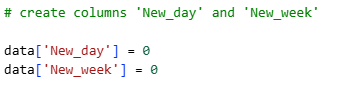

In [133]:
data['New_day'] = 0
data['New_week'] = 0

In [134]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [135]:
# Fill in "1" when the new day starts

data.loc[data["Local_time_T_Delta"] > '0 days 00:05:00', 'New_day'] = 1

.........................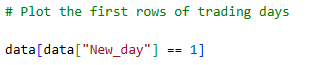

In [136]:
data[data["New_day"] == 1]

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta,New_day,New_week
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,...,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00,NaT,2 days 01:01:00,1,0
276,2058.018,2059.134,2058.018,2058.758,0.04366,2059.772,2059.882,2058.952,2059.292,0.03770,...,0.00596,1.754,0.748,0.934,0.534,2024-01-02 23:00:00+00:00,2024-01-02 21:55:00+00:00,0 days 01:05:00,1,0
552,2041.895,2042.425,2041.398,2042.044,0.09643,2042.452,2043.075,2042.015,2042.532,0.10547,...,0.00904,0.557,0.650,0.617,0.488,2024-01-03 23:00:00+00:00,2024-01-03 21:55:00+00:00,0 days 01:05:00,1,0
828,2043.218,2043.685,2042.774,2042.864,0.03565,2044.812,2045.092,2043.302,2043.302,0.02107,...,0.01458,1.594,1.407,0.528,0.438,2024-01-04 23:00:00+00:00,2024-01-04 21:55:00+00:00,0 days 01:05:00,1,0
1104,2044.385,2045.005,2042.825,2044.494,0.16514,2046.355,2046.445,2043.702,2044.966,0.13458,...,0.03056,1.970,1.440,0.877,0.472,2024-01-07 23:00:00+00:00,2024-01-05 21:55:00+00:00,2 days 01:05:00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34104,2333.205,2334.395,2333.205,2333.748,0.07701,2335.000,2335.000,2333.975,2334.245,0.03176,...,0.04525,1.795,0.605,0.770,0.497,2024-06-24 22:00:00+00:00,2024-06-24 20:55:00+00:00,0 days 01:05:00,1,0
34380,2319.575,2319.935,2318.705,2319.925,0.04851,2320.165,2320.655,2319.365,2320.375,0.06285,...,0.01434,0.590,0.720,0.660,0.450,2024-06-25 22:00:00+00:00,2024-06-25 20:55:00+00:00,0 days 01:05:00,1,0
34656,2298.098,2299.055,2297.898,2298.694,0.07182,2299.492,2299.725,2298.736,2299.216,0.07026,...,0.00156,1.394,0.670,0.838,0.522,2024-06-26 22:00:00+00:00,2024-06-26 20:55:00+00:00,0 days 01:05:00,1,0
34932,2327.108,2327.915,2326.875,2326.905,0.02414,2328.992,2328.992,2327.295,2327.315,0.04502,...,0.02088,1.884,1.077,0.420,0.410,2024-06-27 22:00:00+00:00,2024-06-27 20:55:00+00:00,0 days 01:05:00,1,0


In [137]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [138]:
# Fill in "1" when the new week starts

data.loc[data["Local_time_T_Delta"] > '1 days 00:00:00', 'New_week'] = 1

...............................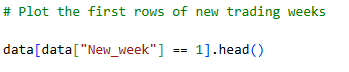

In [139]:
data[data["New_week"] == 1].head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta,New_day,New_week
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,...,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00,NaT,2 days 01:01:00,1,1
1104,2044.385,2045.005,2042.825,2044.494,0.16514,2046.355,2046.445,2043.702,2044.966,0.13458,...,0.03056,1.970,1.440,0.877,0.472,2024-01-07 23:00:00+00:00,2024-01-05 21:55:00+00:00,2 days 01:05:00,1,1
2484,2048.498,2048.598,2046.698,2047.705,0.22412,2050.302,2050.302,2047.302,2048.216,0.21842,...,0.00570,1.804,1.704,0.604,0.511,2024-01-14 23:00:00+00:00,2024-01-12 21:55:00+00:00,2 days 01:05:00,1,1
3834,2029.715,2029.715,2027.915,2028.505,0.12920,2030.305,2030.365,2028.502,2029.042,0.12594,...,0.00326,0.590,0.650,0.587,0.537,2024-01-21 23:00:00+00:00,2024-01-19 21:55:00+00:00,2 days 01:05:00,1,1
5214,2024.215,2027.014,2022.854,2023.515,0.25994,2025.245,2027.776,2023.545,2024.145,0.27963,...,0.01969,1.030,0.762,0.691,0.630,2024-01-28 23:00:00+00:00,2024-01-26 21:55:00+00:00,2 days 01:05:00,1,1


In [140]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [141]:
# drop the columns that are no longer needed,
# since the time series is regular
# (each line is the next 5-minutes, except for the marked lines in the New_day and New_week columns

data2 = data.drop(['Local_time_T', 'Local_time_T_shipt_1_Down', 'Local_time_T_Delta'],axis=1)

..............................image.png

In [142]:
data2.head(3)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472,1,1
1,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447,0,0
2,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371,0,0


.......................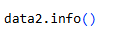

In [143]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float64
 1   High_Bid          35232 non-null  float64
 2   Low_Bid           35232 non-null  float64
 3   Close_Bid         35232 non-null  float64
 4   Volume_Bid        35232 non-null  float64
 5   Open_Ask          35232 non-null  float64
 6   High_Ask          35232 non-null  float64
 7   Low_Ask           35232 non-null  float64
 8   Close_Ask         35232 non-null  float64
 9   Volume_Ask        35232 non-null  float64
 10  Volume_Delta      35232 non-null  float64
 11  Volume_Delta_abs  35232 non-null  float64
 12  Open_Delta        35232 non-null  float64
 13  High_Delta        35232 non-null  float64
 14  Low_Delta         35232 non-null  float64
 15  Close_Delta       35232 non-null  float64
 16  New_day           35232 non-null  int64 

...........................image.png

In [144]:
data = []

In [145]:
# !!!! We will look for rows with potential take-profit = $10


- create 'High_Bid' and 'Low_Ask' 4 hours ahead
- that is, the maximum holding of a position is no more than 4 hours
- 4 hours is 48 of 5-minute intervals


..................................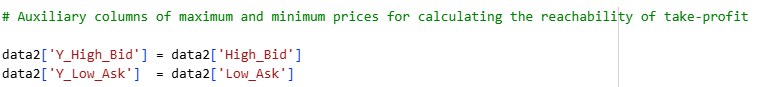

In [146]:
data2['Y_High_Bid'] = data2['High_Bid']
data2['Y_Low_Ask'] = data2['Low_Ask']


............................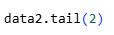

In [147]:
data2.tail(2)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
35230,2325.515,2325.525,2325.125,2325.385,0.09813,2325.945,2325.945,2325.555,2325.795,0.02880,-0.06933,0.06933,0.430,0.420,0.430,0.41,0,0,2325.525,2325.555
35231,2325.438,2325.438,2324.625,2324.825,0.07851,2325.825,2325.835,2325.066,2325.245,0.07257,-0.00594,0.00594,0.387,0.397,0.441,0.42,0,0,2325.438,2325.066


<html> <h3 style="font-style:italic; color:blue;"> Data Normalisation </h3> </html>

In [148]:
# We do price normalisation simply by dividing all prices by 1000 (for Gold)
# It is not essential that the normalised prices were in the range between [0,1]
# It is more important that the variables were approximately of the same order

In [149]:
# Only applicable to Volumes and Deltas:

# normalisation
# data=(data-data.min())/(data.max()-data.min())

##### Find Max and Min for Prices, Volumes and Deltas

In [150]:
# Max price is Max High_Ask
# Min price is Min Low_Bid

# Max Volume = Max{Volume_Bid, Volume_Ask}
# Min Volume = 0

# Max_Delta = Max{Open_Delta, High_Delta, Low_Delta, Close_Delta}
# Min_Delta = Min{Open_Delta, High_Delta, Low_Delta, Close_Delta}

In [151]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 19 cells with code.

In [152]:
max_price = (data2['High_Ask']).max()
max_price

2450.325

In [153]:
min_price = data2['Low_Bid'].min()
min_price

1984.088

In [154]:
max_volume = max(max(data2['Volume_Bid']), max(data2['Volume_Ask']))
max_volume

2.84268

In [155]:
max_Delta = max(max(data2['Open_Delta']), max(data2['High_Delta']), max(data2['Low_Delta']), max(data2['Close_Delta']))
max_Delta

5.9809999999999945

In [156]:
max_Delta = round(max_Delta, 3)
max_Delta

5.981

In [157]:
min_Delta = min(min(data2['Open_Delta']), min(data2['High_Delta']), min(data2['Low_Delta']), min(data2['Close_Delta']))
min_Delta

0.0010000000002037268

In [158]:
min_Delta = round(min_Delta, 3)
min_Delta

0.001

In [159]:
max_volume_Delta = data2['Volume_Delta'].max()
max_volume_Delta

2.70359

In [160]:
max_volume_Delta = round(max_volume_Delta, 5)
max_volume_Delta

2.70359

In [161]:
min_volume_Delta = data2['Volume_Delta'].min()
min_volume_Delta

-1.0644

In [162]:
min_volume_Delta = round(min_volume_Delta, 5)
min_volume_Delta

-1.0644

In [163]:
max_volume_Delta_abs = data2['Volume_Delta_abs'].max()
max_volume_Delta_abs

2.70359

In [164]:
max_volume_Delta_abs = round(max_volume_Delta_abs, 5)
max_volume_Delta_abs

2.70359

In [165]:
min_volume_Delta_abs = data2['Volume_Delta_abs'].min()
min_volume_Delta_abs

0.0

In [166]:
# min_volume_Delta_abs = 0
# Therefore, the normalization formula for volume_Delta_abs is simplified

#### Normalise
Run each cell only one time !

In [167]:
# Цены просто делим на 100

data2['Open_Bid']   = data2['Open_Bid']   / 1000
data2['High_Bid']   = data2['High_Bid']   / 1000
data2['Low_Bid']    = data2['Low_Bid']    / 1000
data2['Close_Bid']  = data2['Close_Bid']  / 1000

data2['Open_Ask']   = data2['Open_Ask']   / 1000
data2['High_Ask']   = data2['High_Ask']   / 1000
data2['Low_Ask']    = data2['Low_Ask']    / 1000
data2['Close_Ask']  = data2['Close_Ask']  / 1000

data2['Y_High_Bid'] = data2['Y_High_Bid'] / 1000
data2['Y_Low_Ask']  = data2['Y_Low_Ask']  / 1000



In [168]:
data2['Volume_Ask']  = data2['Volume_Ask'] / max_volume
data2['Volume_Bid']  = data2['Volume_Bid'] / max_volume

In [169]:
data2['Volume_Delta'] = ( data2['Volume_Delta'] - min_volume_Delta ) / (max_volume_Delta-min_volume_Delta)

In [170]:
data2['Volume_Delta_abs']  = data2['Volume_Delta_abs'] / max_volume_Delta_abs

In [171]:
# For the price deltas, the minimum difference is more interesting, therefore we apply inverse normalisation
# data= 1 - (data - data.min()) / (data.max() - data.min()) = (data.max() - data) / (data.max() - data.min())


In [172]:
data2['Open_Delta']  = ( max_Delta - data2['Open_Delta'] )  / (max_Delta-min_Delta)
data2['High_Delta']  = ( max_Delta - data2['High_Delta'] )  / (max_Delta-min_Delta)
data2['Low_Delta']   = ( max_Delta - data2['Low_Delta'] )   / (max_Delta-min_Delta)
data2['Close_Delta'] = ( max_Delta - data2['Close_Delta'] ) / (max_Delta-min_Delta)

............................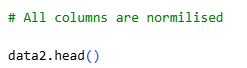

In [173]:
data2.head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
0,2.062598,2.066595,2.062405,2.065214,0.042256,2.064562,2.067475,2.064075,2.065686,0.041661,0.282036,0.000625,0.671739,0.853010,0.720903,0.921237,1,1,2.066595,2.064075
1,2.065185,2.065194,2.063851,2.064455,0.022894,2.065616,2.065839,2.064476,2.064902,0.024294,0.283541,0.001472,0.928094,0.892308,0.895652,0.925418,0,0,2.065194,2.064476
2,2.064424,2.066365,2.064395,2.065734,0.013878,2.064902,2.066825,2.064752,2.066105,0.014785,0.283170,0.000954,0.920234,0.923244,0.940468,0.938127,0,0,2.066365,2.064752
3,2.065715,2.066075,2.065055,2.065585,0.015429,2.066105,2.066525,2.065415,2.065986,0.011261,0.279340,0.004383,0.934950,0.924916,0.939967,0.933110,0,0,2.066075,2.065415
4,2.065585,2.065815,2.065295,2.065555,0.011155,2.065992,2.066242,2.065645,2.065855,0.011640,0.282851,0.000510,0.932107,0.928763,0.941639,0.950000,0,0,2.065815,2.065645


.........................image.png

In [174]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float64
 1   High_Bid          35232 non-null  float64
 2   Low_Bid           35232 non-null  float64
 3   Close_Bid         35232 non-null  float64
 4   Volume_Bid        35232 non-null  float64
 5   Open_Ask          35232 non-null  float64
 6   High_Ask          35232 non-null  float64
 7   Low_Ask           35232 non-null  float64
 8   Close_Ask         35232 non-null  float64
 9   Volume_Ask        35232 non-null  float64
 10  Volume_Delta      35232 non-null  float64
 11  Volume_Delta_abs  35232 non-null  float64
 12  Open_Delta        35232 non-null  float64
 13  High_Delta        35232 non-null  float64
 14  Low_Delta         35232 non-null  float64
 15  Close_Delta       35232 non-null  float64
 16  New_day           35232 non-null  int64 

In [175]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 4 cells with code.

In [176]:
# Reducing memory size

columns_float =['Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
                'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask',
                'Volume_Delta', 'Volume_Delta_abs',
                'Open_Delta', 'High_Delta', 'Low_Delta', 'Close_Delta',
                'Y_High_Bid', 'Y_Low_Ask']

columns_integer =['New_day', 'New_week']



In [177]:
for column in columns_float:
    data2[column] = pd.to_numeric(data2[column], downcast='float')

for column in columns_integer:
    data2[column] = pd.to_numeric(data2[column], downcast='integer')

data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float32
 1   High_Bid          35232 non-null  float32
 2   Low_Bid           35232 non-null  float32
 3   Close_Bid         35232 non-null  float32
 4   Volume_Bid        35232 non-null  float32
 5   Open_Ask          35232 non-null  float32
 6   High_Ask          35232 non-null  float32
 7   Low_Ask           35232 non-null  float32
 8   Close_Ask         35232 non-null  float32
 9   Volume_Ask        35232 non-null  float32
 10  Volume_Delta      35232 non-null  float32
 11  Volume_Delta_abs  35232 non-null  float32
 12  Open_Delta        35232 non-null  float32
 13  High_Delta        35232 non-null  float32
 14  Low_Delta         35232 non-null  float32
 15  Close_Delta       35232 non-null  float32
 16  New_day           35232 non-null  int8  

In [178]:
data2.shape

(35232, 20)

<Figure size 1200x500 with 0 Axes>

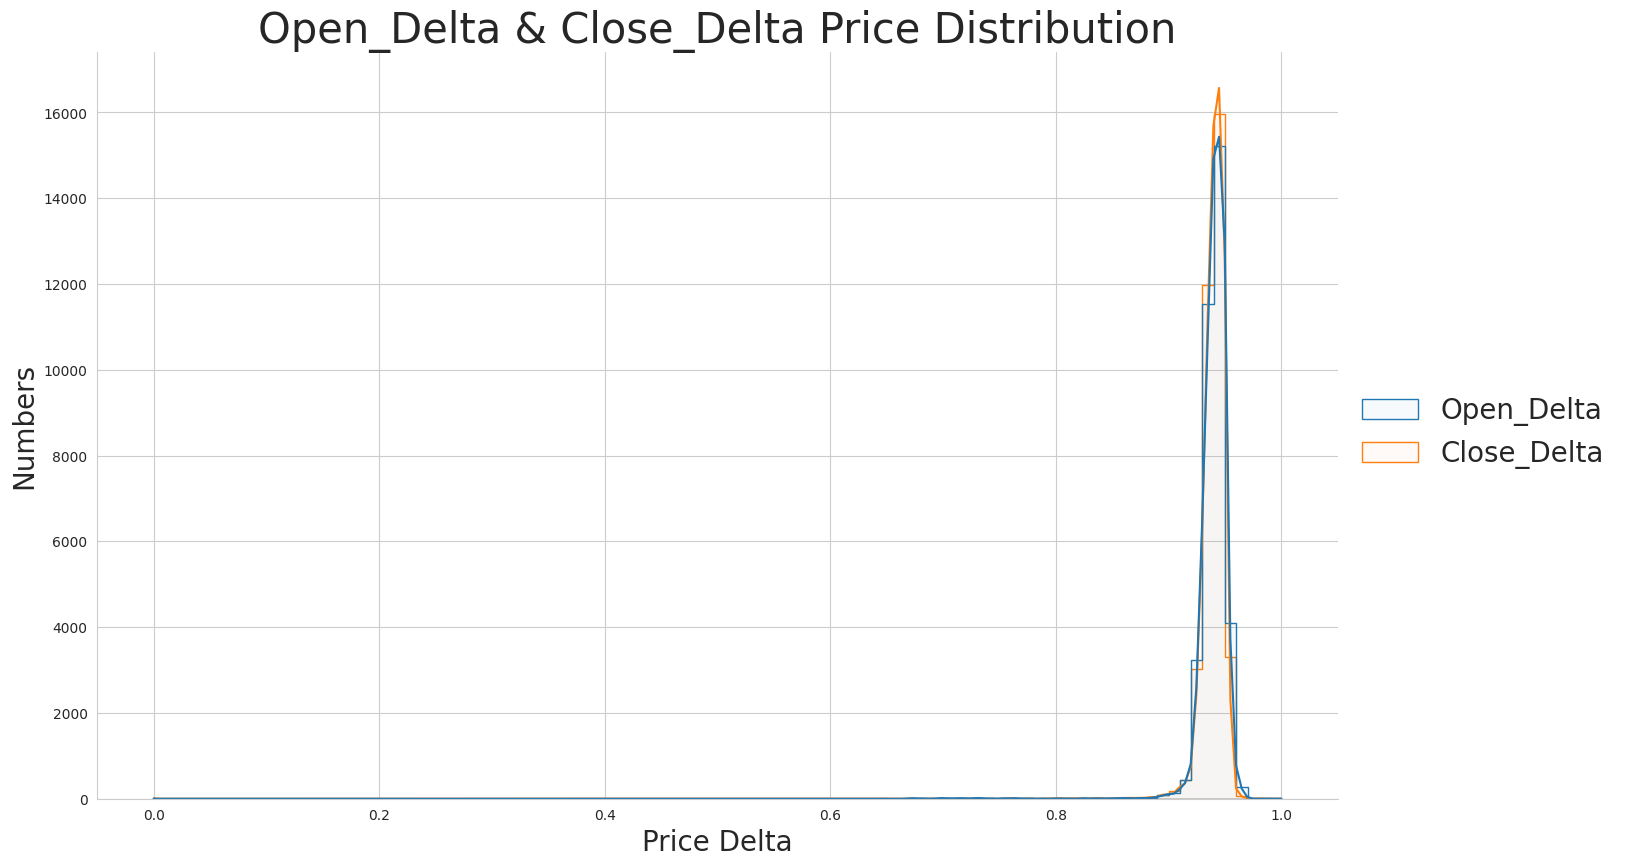

In [179]:
# inverse normalisation of price deltas, the minimum difference is more interesting

fig = plt.figure(figsize=(12, 5))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data2[['Open_Delta', 'Close_Delta']],
            height=8,
            aspect=1.7,
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('Open_Delta & Close_Delta Price Distribution')
plt.xlabel('Price Delta', size= 20)
plt.ylabel('Numbers', size= 20)
plt.show();

### Date transformation


In [180]:
# We will predict Wait-Attention modes
# Since we have a 5-minute dataset, Then we will shift MiN & MAX prices by 48 rows, which is 4 hours forward

In [181]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 3 cells.

In [182]:
# Rows number

n=data2.shape[0]
n

35232

In [183]:
# Colonms number

p=data2.shape[1]
p

20

In [184]:
# Forward-looking window
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=48)


# create new columns: MIN_Lowest(Low_Ask) and MAX_Highest(High_Bid) prices of DURING NEXT 4 hours
# 48 rows of 5-minute time-frame each

data2['Y_High_Bid_4h'] = data2['Y_High_Bid'].rolling(window=indexer).max()
data2['Y_Low_Ask_4h']  = data2['Y_Low_Ask'].rolling(window=indexer).min()

.............................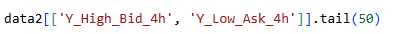

In [185]:
data2[['Y_High_Bid_4h', 'Y_Low_Ask_4h']].tail(50)

,Y_High_Bid_4h,Y_Low_Ask_4h
35182,2.326775,2.323125
35183,2.326775,2.323125
35184,2.326775,2.323125
35185,NaN,NaN
35186,NaN,NaN
35187,NaN,NaN
35188,NaN,NaN
35189,NaN,NaN
35190,NaN,NaN
35191,NaN,NaN


In [186]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [187]:
# delete the last 48 rows (because we don't have prices for the last 4 hours)

for i in range(48):
        data2.drop(data2.shape[0]-1, axis=0, inplace=True)

..........................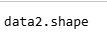

In [188]:
data2.shape

(35184, 22)

.............................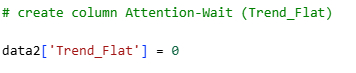

In [189]:
data2['Trend_Flat'] = 0

In [190]:
# Please read the following code carefully! This is the process of generating outputs, or labeling.

In [191]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 2 cells.

In [192]:
# Fill in "1s" If the movement (in any direction) within 4 hours is more than $10 (0.01 after the normalisation)

data2.loc[ (data2["Y_High_Bid_4h"] - data2["Close_Ask"]) >= 0.01, 'Trend_Flat'] = 1
print( data2['Trend_Flat'].sum() )

data2.loc[ (data2["Close_Bid"] - data2["Y_Low_Ask_4h"]) >= 0.01, 'Trend_Flat'] = 1
print( data2['Trend_Flat'].sum() )

5767
10758


In [193]:
print(((data2["Y_High_Bid_4h"] - data2["Close_Ask"])>= 0.01).sum())
print(((data2["Close_Bid"] - data2["Y_Low_Ask_4h"])>= 0.01).sum())

5767
5450


In [194]:
# (5767+5450) = 11217
# 11217-10758 = 459       # rows after which the price moved in both directions by $10 or more

..........................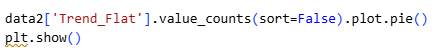

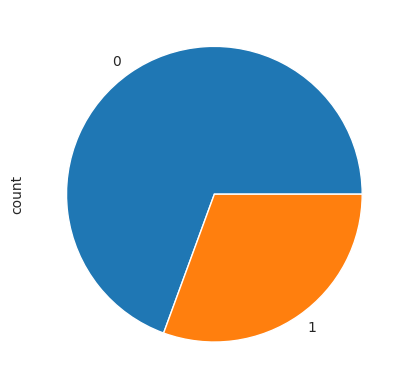

In [195]:
data2['Trend_Flat'].value_counts(sort=False).plot.pie()
plt.show()

In [196]:
# The dataset is unbalanced

..................................image.png

In [197]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35184 entries, 0 to 35183
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35184 non-null  float32
 1   High_Bid          35184 non-null  float32
 2   Low_Bid           35184 non-null  float32
 3   Close_Bid         35184 non-null  float32
 4   Volume_Bid        35184 non-null  float32
 5   Open_Ask          35184 non-null  float32
 6   High_Ask          35184 non-null  float32
 7   Low_Ask           35184 non-null  float32
 8   Close_Ask         35184 non-null  float32
 9   Volume_Ask        35184 non-null  float32
 10  Volume_Delta      35184 non-null  float32
 11  Volume_Delta_abs  35184 non-null  float32
 12  Open_Delta        35184 non-null  float32
 13  High_Delta        35184 non-null  float32
 14  Low_Delta         35184 non-null  float32
 15  Close_Delta       35184 non-null  float32
 16  New_day           35184 non-null  int8  

In [198]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [199]:
# remove unused columns

data2 = data2.drop(['Y_High_Bid', 'Y_Low_Ask','Y_High_Bid_4h', 'Y_Low_Ask_4h'],axis=1)

............................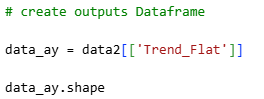

In [200]:
data_ay = data2[['Trend_Flat']]

data_ay.shape

(35184, 1)

...........................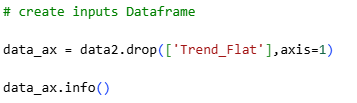

In [201]:
data_ax = data2.drop(['Trend_Flat'],axis=1)

data_ax.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35184 entries, 0 to 35183
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35184 non-null  float32
 1   High_Bid          35184 non-null  float32
 2   Low_Bid           35184 non-null  float32
 3   Close_Bid         35184 non-null  float32
 4   Volume_Bid        35184 non-null  float32
 5   Open_Ask          35184 non-null  float32
 6   High_Ask          35184 non-null  float32
 7   Low_Ask           35184 non-null  float32
 8   Close_Ask         35184 non-null  float32
 9   Volume_Ask        35184 non-null  float32
 10  Volume_Delta      35184 non-null  float32
 11  Volume_Delta_abs  35184 non-null  float32
 12  Open_Delta        35184 non-null  float32
 13  High_Delta        35184 non-null  float32
 14  Low_Delta         35184 non-null  float32
 15  Close_Delta       35184 non-null  float32
 16  New_day           35184 non-null  int8  

........................image.png

In [202]:
data_ax.shape

(35184, 18)

In [203]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 2 cells.

In [204]:
# Create inputs Numpy

data_a = np.array(data_ax)

with np.printoptions(precision=4):
    print("data_a:")
    print(data_a[:2,:])
    print('\n')
    print(data_a[-2:,:])

print("numpy size: = ", data_a.shape)
print("type: ", data_a.dtype)


data_a:
[[2.0626e+00 2.0666e+00 2.0624e+00 2.0652e+00 4.2256e-02 2.0646e+00
  2.0675e+00 2.0641e+00 2.0657e+00 4.1661e-02 2.8204e-01 6.2509e-04
  6.7174e-01 8.5301e-01 7.2090e-01 9.2124e-01 1.0000e+00 1.0000e+00]
 [2.0652e+00 2.0652e+00 2.0639e+00 2.0645e+00 2.2894e-02 2.0656e+00
  2.0658e+00 2.0645e+00 2.0649e+00 2.4294e-02 2.8354e-01 1.4721e-03
  9.2809e-01 8.9231e-01 8.9565e-01 9.2542e-01 0.0000e+00 0.0000e+00]]


[[2.3258 2.326  2.3256 2.3259 0.0276 2.3261 2.3263 2.3259 2.3262 0.0538
  0.3023 0.0276 0.9393 0.9455 0.9472 0.9393 0.     0.    ]
 [2.3259 2.326  2.3252 2.3257 0.0503 2.3262 2.3264 2.3256 2.326  0.0558
  0.2866 0.0058 0.9455 0.9393 0.94   0.9393 0.     0.    ]]
numpy size: =  (35184, 18)
type:  float32


In [205]:
# Create outputs Numpy

data_y = np.array(data_ay)

print("data_a:")
print(data_y[:3,:])
print('\n')
print(data_y[-3:,:])

print("numpy size: = ", data_y.shape)
print("type: ", data_y.dtype)

data_a:
[[0]
 [0]
 [0]]


[[0]
 [0]
 [0]]
numpy size: =  (35184, 1)
type:  int64


........................image.png

In [206]:
len(data_a)

35184

#### Create the 3D inputs tensor, and 2D outputs matrix

In [207]:
# Analysis of the entire dataset would take a long time,
# so, please reduce the dataset by about 3 times to 12000 rows

# n_small = 12000 rows (5-minutes), which is around 2 months.

In [208]:
# We need a three-dimensional data tensor: [(n_small-N ), N, 18] and
# one-dimensional array of answers [(n_small-N ), 1] with the High and Low prices DURING the next 5 minutes

# where N=50 is the number of minutes for analysis at each step; those are looking backwards

# Therefore, we need:
# three-dimensional data tensor of sliced graphs [(n_small - N - 5), N, 18] and
# two-dimensional matrix of answers Y[(n_small - N - 5), 2]
# with the Trend-Flat indicator, indicating whether take profit will be reached within 4 hours or not

In [209]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 5 cells.

In [210]:
# Progress bar

from tqdm import tqdm

In [211]:
# n_small = len(data_y)

n_small = 12000    # reduce the dataset size

N=50               # sliding window depth

L=n_small-N        # number of sliding window slices
t=data_a.shape[1]  # features number
print('Size of a three-dimensional inputs tensor: ',L,N,t)


Size of a three-dimensional inputs tensor:  11950 50 18


In [212]:
# create imputs zeros 3D tensors with 'float32'

data_b = np.zeros( (L, N, t), dtype= 'float32' )

In [213]:
# create a one-dimensional zeros vector of answers

Y = np.zeros((L, 1), dtype= 'float32')  # We will predict Attention - Wait for signals

In [214]:
# fill the imputs 3D tansor (data_b)
# and the array of answers Y


print('L = n_small - N = ', n_small-N, L)
for k in tqdm(range(L)):
    data_b[k, :, :] = data_a[k:k+N, :]

    Y[k,0] = data_y[k+N-1,0]   # Trend-Flat signal

print(k)                       # index value (for control)

print('data_b:', '\n', data_b)
print("Numpy size:        ", data_b.shape, '\n')

print( Y[:5,:])
print( Y[-10:,:])
print(      "Numpy size:         ", Y.shape)

L = n_small - N =  11950 11950


100%|██████████| 11950/11950 [00:00<00:00, 230729.97it/s]

11949
data_b: 
 [[[2.062598   2.066595   2.062405   ... 0.92123747 1.         1.        ]
  [2.065185   2.065194   2.063851   ... 0.9254181  0.         0.        ]
  [2.064424   2.066365   2.064395   ... 0.9381271  0.         0.        ]
  ...
  [2.067375   2.067745   2.067238   ... 0.9438127  0.         0.        ]
  [2.067695   2.067725   2.066445   ... 0.95167226 0.         0.        ]
  [2.066995   2.068605   2.066958   ... 0.95167226 0.         0.        ]]

 [[2.065185   2.065194   2.063851   ... 0.9254181  0.         0.        ]
  [2.064424   2.066365   2.064395   ... 0.9381271  0.         0.        ]
  [2.065715   2.066075   2.065055   ... 0.93311036 0.         0.        ]
  ...
  [2.067695   2.067725   2.066445   ... 0.95167226 0.         0.        ]
  [2.066995   2.068605   2.066958   ... 0.95167226 0.         0.        ]
  [2.068455   2.069415   2.068408   ... 0.95167226 0.         0.        ]]

 [[2.064424   2.066365   2.064395   ... 0.9381271  0.         0.        ]
  [2.0

........................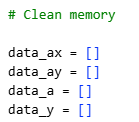

In [215]:
data_ax = []
data_ay = []
data_a = []
data_y = []

### Train Test Split
- 90% for training and validation
- 10% for testing

.........................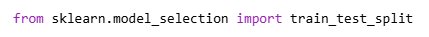

In [216]:
from sklearn.model_selection import train_test_split

<html> <h3 style="font-style:bold; color:red;"> !!! Use parameters: shuffle = False, stratify = None

Otherwise, the whole time series will be mixed up!
</h3> </html>

In [217]:
# Please read the following code carefully. This is the formation of the train and the test datasets.

In [218]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [219]:
# Separate "data_b" and "Y" into X_train, X_test, y_train, y_test i.e. getting training and testing set for the model.

X_train, X_test, y_train, y_test = train_test_split(data_b, Y, test_size=0.1,
                                                    shuffle = False, stratify = None,
                            # random_state - int for reproducible output across multiple function calls
                                                    random_state=101)

..............................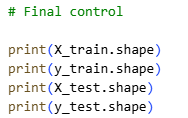

In [220]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10755, 50, 18)
(10755, 1)
(1195, 50, 18)
(1195, 1)


#### Balancing Classes in the Dataset

In [221]:
# Use class weights (class_weight) in the fit method to make the model "pay more attention" to the smaller class.

In [222]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 4 cells.

In [223]:
from sklearn.utils.class_weight import compute_class_weight

In [224]:
y_train.ndim   #  y_train dimension

2

In [225]:
# compute_class_weight only operates on one-dimensional arrays of output data.
# Convert y_train_1 and y_test_1 to one-dimensional arrays

y_train_1 = y_train.ravel()
y_test_1  = y_test.ravel()

print(y_train_1.shape)
print(y_test_1.shape)

(10755,)
(1195,)


In [226]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_1), y=y_train_1)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

.............................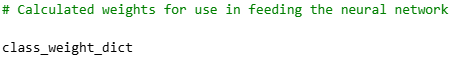

In [227]:
class_weight_dict

{0: np.float64(0.5886699507389163), 1: np.float64(3.3194444444444446)}

### Training

#### LSTM

.......................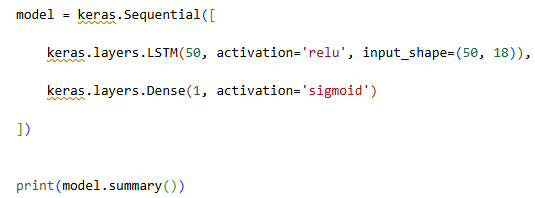

In [228]:
from tensorflow import keras

model = keras.Sequential([
    keras.Input(shape=(50, 18)),  # Explicitly define input shape
    keras.layers.LSTM(50, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        13,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,851 (54.11 KB)

 Trainable params: 13,851 (54.11 KB)

 Non-trainable params: 0 (0.00 B)

None


#### Callbacks

..................................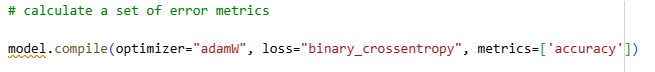

In [229]:
model.compile(optimizer="adamW", loss="binary_crossentropy", metrics=['accuracy'])

.............................image.png

In [230]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

..........................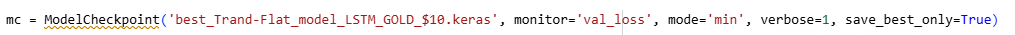

In [231]:
mc = ModelCheckpoint('best_Trand-Flat_model_LSTM_GOLD_$10.h5', monitor='val_loss', mode='min', verbose=1, save_best_only=True)

<html> <h4 style="font-style:bold; color:blue;"> If you are using your own laptop without a GPU (Graphics processing unit),

please change the following parameter in the next cell
</h4> </html>

<html> <h4 style="font-style:bold; color:red;">
epochs=10
</h4> </html>


..............................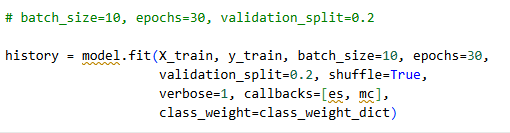

In [232]:
history = model.fit(X_train, y_train, batch_size=10, epochs=30,
                    validation_split=0.2, shuffle=True,
                    verbose=1, callbacks=[es, mc],
                    class_weight=class_weight_dict)

Epoch 1/30
861/861 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2643 - loss: 0.7401
Epoch 1: val_loss improved from inf to 0.76864, saving model to best_Trand-Flat_model_LSTM_GOLD_$10.h5


861/861 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2644 - loss: 0.7400 - val_accuracy: 0.2445 - val_loss: 0.7686
Epoch 2/30
853/861 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4450 - loss: 0.6901
Epoch 2: val_loss improved from 0.76864 to 0.59725, saving model to best_Trand-Flat_model_LSTM_GOLD_$10.h5


861/861 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4453 - loss: 0.6900 - val_accuracy: 0.6629 - val_loss: 0.5973
Epoch 3/30
859/861 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5482 - loss: 0.6627
Epoch 3: val_loss did not improve from 0.59725
861/861 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5482 - loss: 0.6627 - val_accuracy: 0.2599 - val_loss: 0.9469
Epoch 4/30
857/861 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4982 - loss: 0.7610
Epoch 4: val_loss did not improve from 0.59725
861/861 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4981 - loss: 0.7613 - val_accuracy: 0.5165 - val_loss: 0.6643
Epoch 5/30
854/861 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4451 - loss: 0.6874
Epoch 5: val_loss improved from 0.59725 to 0.57428, saving model to best_Trand-Flat_model_LSTM_GOLD_$10.h5


861/861 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4451 - loss: 0.6874 - val_accuracy: 0.7843 - val_loss: 0.5743
Epoch 6/30
854/861 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4538 - loss: 0.6687
Epoch 6: val_loss did not improve from 0.57428
861/861 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4540 - loss: 0.6687 - val_accuracy: 0.4598 - val_loss: 0.6691
Epoch 7/30
856/861 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5101 - loss: 0.6577
Epoch 7: val_loss improved from 0.57428 to 0.52463, saving model to best_Trand-Flat_model_LSTM_GOLD_$10.h5


861/861 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5101 - loss: 0.6576 - val_accuracy: 0.8415 - val_loss: 0.5246
Epoch 8/30
853/861 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5327 - loss: 0.6530
Epoch 8: val_loss did not improve from 0.52463
861/861 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5330 - loss: 0.6529 - val_accuracy: 0.5779 - val_loss: 0.6329
Epoch 9/30
859/861 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5517 - loss: 0.6613
Epoch 9: val_loss did not improve from 0.52463
861/861 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5517 - loss: 0.6613 - val_accuracy: 0.7643 - val_loss: 0.5880
Epoch 10/30
858/861 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5682 - loss: 0.6436
Epoch 10: val_loss did not improve from 0.52463
861/861 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5681 - loss: 0.6436 - val_accuracy: 0.5635 - val_loss: 0.6265
Epoch 11/30
858/861 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4719 - loss: 0.6699
Epoch 11: val_loss did not improve from 0.52

................................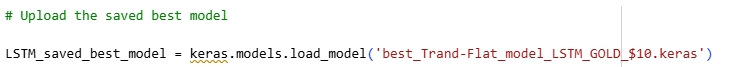

In [233]:
# Upload the saved best model
LSTM_saved_best_model = keras.models.load_model('best_Trand-Flat_model_LSTM_GOLD_$10.h5')

#### Test

..................................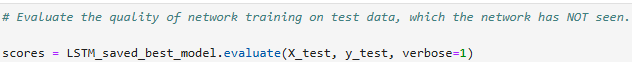

In [234]:
scores = LSTM_saved_best_model.evaluate(X_test, y_test, verbose=1)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7520 - loss: 0.5710


...............................image.png

In [235]:
scores

[0.5571327209472656, 0.7665271759033203]

### Visualisation

#### Loss function graphs during training

In [236]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 2 cells.

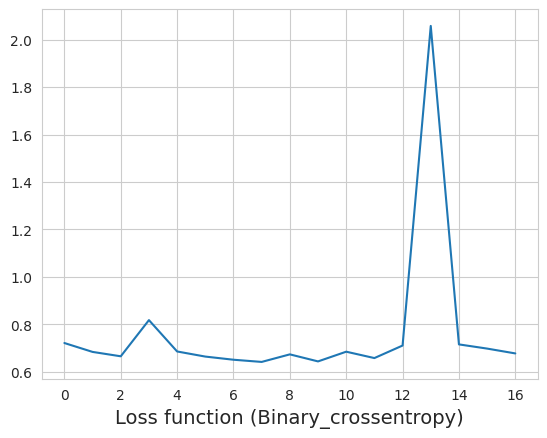

In [237]:
# Training Loss function

plt.plot(history.history['loss'])
plt.xlabel('Loss function (Binary_crossentropy)',size=14)
plt.show()

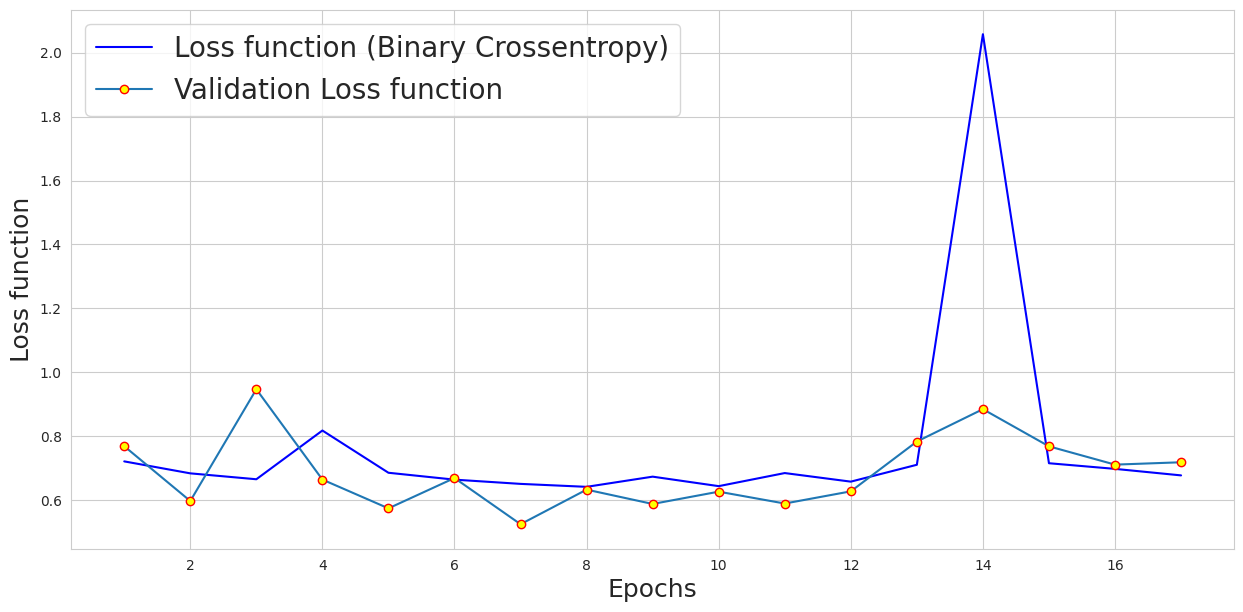

In [238]:
# More detailed Loss function graph

history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(loss) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, loss, 'b', label='Loss function (Binary Crossentropy)')
plt.plot(epochs, val_loss, marker='o', markeredgecolor='red', markerfacecolor='yellow', label='Validation Loss function')
plt.xlabel('Epochs', size=18)
plt.ylabel('Loss function', size=18)
plt.legend()
plt.show()

............................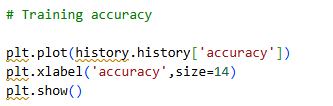

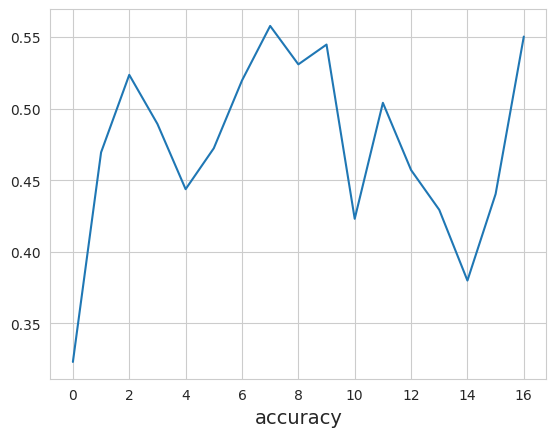

In [239]:
plt.plot(history.history['accuracy'])
plt.xlabel('accuracy', size=14)
plt.show()

................................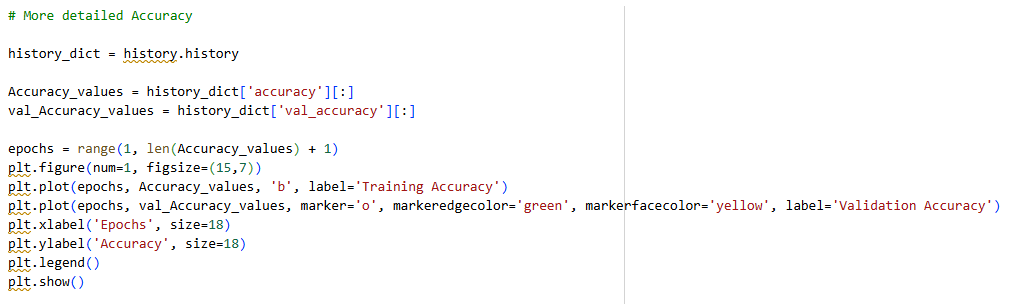

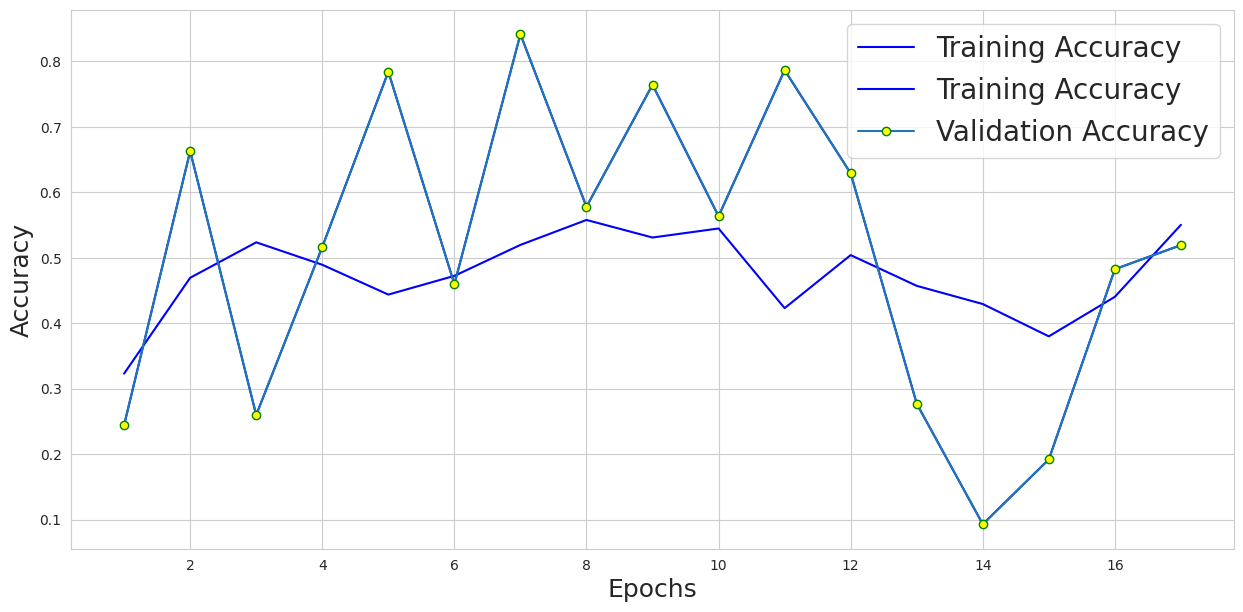

In [240]:
history_dict = history.history

Accuracy_values = history_dict['accuracy'][:]
val_Accuracy_values = history_dict['val_accuracy'][:]

epochs = range(1, len(Accuracy_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, Accuracy_values, 'b', label='Training Accuracy')
plt.plot(epochs, val_Accuracy_values, 'b', label='Training Accuracy')
plt.plot(epochs, val_Accuracy_values, marker='o', markeredgecolor='green', markerfacecolor='yellow', label='Validation Accuracy')
plt.xlabel('Epochs', size=18)
plt.ylabel('Accuracy', size=18)
plt.legend()
plt.show()

.............................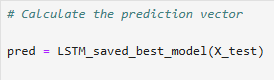

In [241]:
pred = LSTM_saved_best_model(X_test)

.................image.png

In [242]:
print(pred)

tf.Tensor(
[[0.41869166]
 [0.4339062 ]
 [0.44282207]
 ...
 [0.64785725]
 [0.6954173 ]
 [0.67222154]], shape=(1195, 1), dtype=float32)


In [243]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 3 cells.

In [244]:
import random

pred = LSTM_saved_best_model.predict(X_test)

# Check: we take a random element random.randint() and look: what is the difference between test and predict

n_rec = random.randint(0, X_test.shape[0])
print(n_rec)


print("Predicted probability:", pred[n_rec], ", right answer:", y_test[n_rec])


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
297
Predicted probability: [0.43805048] , right answer: [0.]


In [245]:
pred

array([[0.4186915 ],
       [0.4339063 ],
       [0.44282198],
       ...,
       [0.6478574 ],
       [0.6954173 ],
       [0.67222166]], dtype=float32)

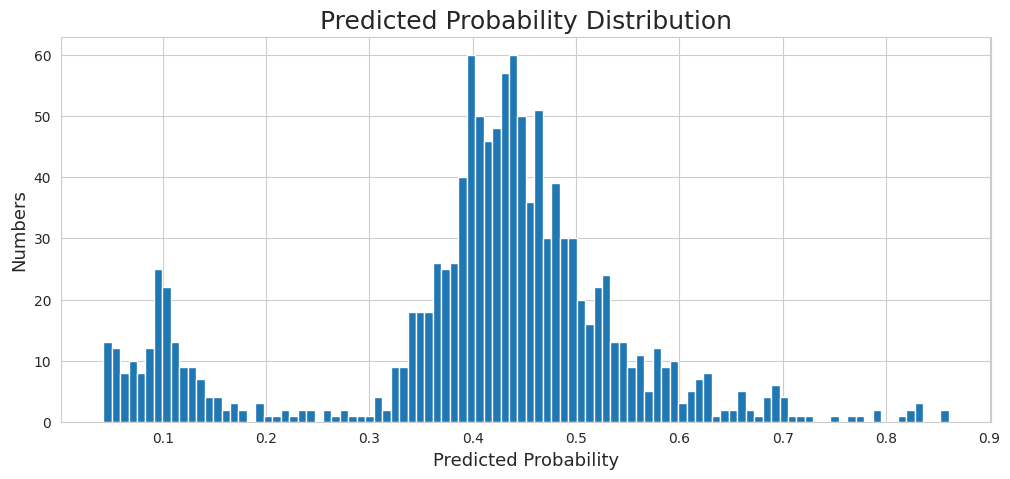

In [246]:
plt.figure(num=1,figsize=(12,5))
plt.hist(pred,bins=100)
plt.title('Predicted Probability Distribution',size=18)
plt.ylabel('Numbers',size=13)
plt.xlabel('Predicted Probability',size=13)
plt.show();

In [247]:
# This cell is for comparison (do not run)

In [248]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 3 cells.

In [249]:
from sklearn.metrics import classification_report

In [250]:
# 50/50 %

pred_binary = np.round(pred)

In [251]:
error_metrics_report = classification_report(y_test, pred_binary)
print(error_metrics_report)

              precision    recall  f1-score   support

         0.0       0.90      0.82      0.86      1058
         1.0       0.19      0.33      0.24       137

    accuracy                           0.77      1195
   macro avg       0.55      0.58      0.55      1195
weighted avg       0.82      0.77      0.79      1195



In [252]:
# This cell is for comparison (do not run)

.........................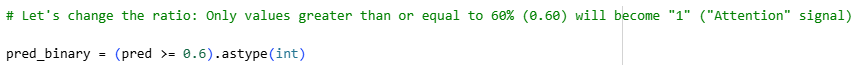

In [253]:
pred_binary = (pred >= 0.6).astype(int)

In [254]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 2 cells.

In [255]:
# Let's change the ratio: Only values ​​greater than or equal to 60% (0.60) will become "1" ("Attention" signal)

pred_binary = (pred >= 0.6).astype(int)

In [256]:
error_metrics_report = classification_report(y_test, pred_binary)
print(error_metrics_report)

              precision    recall  f1-score   support

         0.0       0.89      0.95      0.92      1058
         1.0       0.20      0.09      0.13       137

    accuracy                           0.85      1195
   macro avg       0.55      0.52      0.52      1195
weighted avg       0.81      0.85      0.83      1195



In [257]:
# This cell is for comparison (do not run)

We've increased the Precision for the main signal – "Attention"!
This means we'll enter losing positions less often!

In trading, it's more better to miss sometimes a good signal than to enter a position on an incorrect one.

Precision metric shows what proportion of objects classified by the model as positive are actually positive.
In other words, it answers the question: "Of all the objects the model classified as 'positive,' how many were correct?"

In [258]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [259]:
# Download model

files.download('best_Trand-Flat_model_LSTM_GOLD_$10.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Hyperparameter optimisation

In [260]:
#### Now just press 'CTRL' and 'ENTER' keys on the next cell.

In [261]:
pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


.....................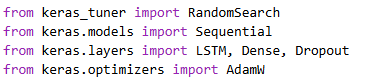

In [262]:
from keras_tuner import RandomSearch
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import AdamW

..................................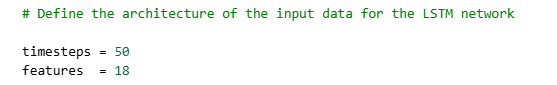

In [263]:
timesteps = 50
features = 18

In [264]:
# Please read the following code carefully. This is the optimisation of neural network hyperparameters.

In [265]:
#### Now just press 'CTRL' and 'ENTER' keys on the 3 next cells.

In [266]:
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=20, max_value=100, step=20),
              return_sequences=True, input_shape=(timesteps, features)))
    model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(LSTM(units=hp.Int('units_2', min_value=10, max_value=50, step=10)))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=AdamW(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [267]:
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,          # How many different models to try
    #max_trials=20,          # Change for reseach
    executions_per_trial=3,  # How many times to train and test each model to average the result
    directory='my_dir',
    project_name='lstm_tuning'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [268]:
# Before running the next cell with the optimiser, remember the file.
# The optimisation process may take time.

In [269]:
tuner.search(X_train, y_train,
             epochs=5,
             #epochs=25,   # Change for reseach
             validation_split=0.2, shuffle=True,
             verbose=1,
             #callbacks=[es, mc],
             class_weight=class_weight_dict)

Trial 5 Complete [00h 00m 52s]
val_accuracy: 0.7833565870920817

Best val_accuracy So Far: 0.7833565870920817
Total elapsed time: 00h 04m 44s


In [270]:
#### Now just press 'CTRL' and 'ENTER' keys on the next 2 cells.

In [271]:
best_model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
print(best_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 20)         │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20)             │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,421 (25.08 KB)

 Trainable params: 6,421 (25.08 KB)

 Non-trainable params: 0 (0.00 B)

None


# Lab Logbook Requirement:

<html> <h3 style="color:red;">
NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK, AND UPLOAD THE LAB LOGBOOK REQUIREMENTS AS A SCREENSHOT OF YOUR CODE AND RESULT(S) ON YOUR GITHUB.
</h3> </html>

<html> <h3 style="; color:blue;">
   
1) Modify the training parameter of the optimised best LSTM model using the following formulas:

Modify the number of epochs:
Z + 30
, where your SID is: XXXXXXZ

Modify the batch_size:
Z + 10
, where your SID is: XXXXXXZ

2) Leave other parameters the same as in the practical session.
3) Use EarlyStopping() and ModelCheckpoint() functions.
4) Train the optimised best LSTM model with the same datasets and your training parameters.
5) Calculate and demonstrate the received test Accuracy and other error metrics for the classification task.
6) Plot the "More detailed Accuracy" graph.
7) Please only add to your Lab Logbook print-screens of:
- code your Use EarlyStopping() and ModelCheckpoint() functions
- code and training result using model.fit()
- the resulting test Accuracy and other error metrics for the classification task using classification_report().
- Accuracy detailed graph
    
</h3> </html>

Epoch 1/34
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5560 - loss: 0.6886 - val_accuracy: 0.4857 - val_loss: 0.6933
Epoch 2/34
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5444 - loss: 0.6903 - val_accuracy: 0.5179 - val_loss: 0.6973
Epoch 3/34
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5204 - loss: 0.6900 - val_accuracy: 0.4750 - val_loss: 0.6946
Epoch 4/34
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5423 - loss: 0.6893 - val_accuracy: 0.5071 - val_loss: 0.6982
Epoch 5/34
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5288 - loss: 0.6925 - val_accuracy: 0.4857 - val_loss: 0.6928
Epoch 6/34
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5436 - loss: 0.6874 - val_accuracy: 0.5250 - val_loss: 0.6955
Epoch 7/34
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5173 - loss: 0.6899 - val_accuracy: 0.4929 - val_loss: 0.6942
Epoch 8/34
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5499 - loss: 0.6867 - val_accuracy: 0.4714 - val_loss

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test Accuracy: 0.5283333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.56      0.31      0.40       303
           1       0.52      0.75      0.61       297

    accuracy                           0.53       600
   macro avg       0.54      0.53      0.51       600
weighted avg       0.54      0.53      0.51       600



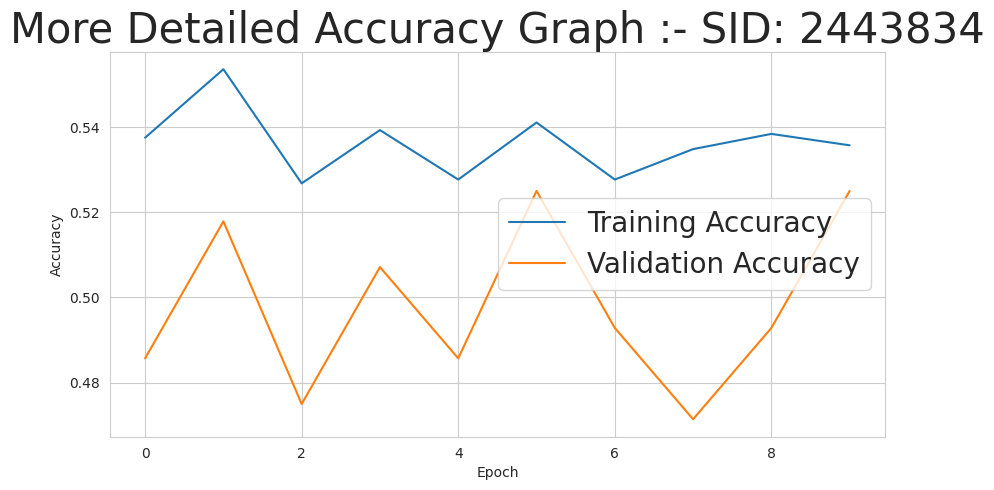

In [273]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# ------------------------
# Callbacks
# ------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='best_lstm_model.keras',
    monitor='val_loss',
    save_best_only=True
)

# ------------------------
# Train model (SID fixed)
# ------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=34,          # Z + 30 = 34
    batch_size=14,      # Z + 10 = 14
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# ------------------------
# Load best model
# ------------------------
best_model = load_model('best_lstm_model.keras')

# ------------------------
# Predict correctly (binary)
# ------------------------
y_prob = best_model.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)
y_true = y_test

# ------------------------
# Accuracy
# ------------------------
test_accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_accuracy)

# ------------------------
# Classification Report
# ------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# ------------------------
# More Detailed Accuracy Graph
# ------------------------
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("More Detailed Accuracy Graph :- SID: 2443834")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
